# Chi-Square Test ($\chi^2$ Test)

The Chi-Square test is a **non-parametric** hypothesis test — unlike the [Z-Test](11_Hypothesis_Testing_Z-Test.ipynb) and [T-Test](09_Hypothesis_Testing_T-Test.ipynb) notebooks, it doesn't compare **means**, it compares **frequencies/counts** of categorical data. It checks whether the values you *observed* ($O$) are close enough to the values you'd *expect* ($E$) under some assumption, or whether they differ by more than chance would explain.

### Applicable in Two Types of Situations

- **Goodness of Fit** — tests whether the observed frequency distribution of a **single categorical variable** matches an expected/theoretical distribution (e.g. "is this die fair?"). This is the case worked through below.
- **Independence** — tests whether **two categorical variables** are related/associated or independent of each other (e.g. "is smoking status independent of gender?"), using a contingency table. See the FAQ at the end for how this differs.

### The Formula

$$\chi^2 = \sum \dfrac{(O_i - E_i)^2}{E_i}$$

Where:
- $O_i$ = **Observed** value/frequency (what actually happened, from the data)
- $E_i$ = **Expected** value/frequency (what should happen if $H_0$ is true)
- The sum is taken over all $i$ categories (here, the 6 faces of the die)

Squaring $(O_i - E_i)$ makes every deviation positive (so an over-count and an under-count don't cancel out) and penalizes bigger deviations more heavily. Dividing by $E_i$ scales the deviation relative to the size of the expected count, so a miss of 5 matters more when $E_i=10$ than when $E_i=1000$.

## Example 1 (Goodness of Fit, Chi-Square Test)

A **fair die** is rolled **120 times** and the following results are obtained:

| Face | 1 | 2 | 3 | 4 | 5 | 6 |
|---|---|---|---|---|---|---|
| Observed frequency | 22 | 17 | 20 | 26 | 22 | 13 |

Test at a **5% level of significance** whether the die is fair.

### Step 1 - State the Null and Alternate Hypothesis

$$H_0: \text{the die is fair (observed frequencies match the expected uniform distribution)}$$
$$H_1: \text{the die is not fair}$$

- $H_0$ (Null Hypothesis) — each face has an equal $\frac{1}{6}$ probability of showing up; any difference between observed and expected counts is just random variation.
- $H_1$ (Alternate Hypothesis) — the faces are **not** equally likely; the die is biased.

Note this is inherently a form of **one-tailed** test in the sense that the Chi-Square statistic is always $\geq 0$ and only the **right tail** (large deviations) leads to rejection — a small $\chi^2$ just means the fit is good, there's no "too fair" side to worry about.

### Step 2 - Significance Value

$$\alpha = 0.05$$

Unlike the two-tailed t-tests in earlier notebooks, $\alpha$ is **not** split across two tails here — the entire 5% sits in the **right tail** of the Chi-Square distribution, since only large positive deviations count as evidence against $H_0$.

### Step 3 - Degrees of Freedom

$$df = n - 1 = 6 - 1 = 5$$

For a **Goodness of Fit** test, `df` is the number of categories ($n=6$ faces) minus 1 — analogous to the [Paired T-Test's](14_Hypothesis_Testing_T-Test_Paired.ipynb) $df=n-1$, but here $n$ counts *categories*, not *pairs of observations*. (The Independence test uses a different formula — see the FAQ.)

### Step 4 - Observed vs Expected Frequencies, and the Chi-Square Statistic

**Observed ($O$):** the actual roll counts — 22, 17, 20, 26, 22, 13.

**Expected ($E$):** if the die were perfectly fair, each of the 6 faces should show up equally often across 120 rolls:

$$E_i = \dfrac{120}{6} = 20 \text{ for every face}$$

Then compute $\chi^2_{calc} = \sum \dfrac{(O_i-E_i)^2}{E_i}$ face by face, exactly like the formula in Step "The Formula" above.

In [1]:
import numpy as np

In [2]:
ob = np.array([22,17,20,26,22,13])

In [3]:
ex = np.array([20,20,20,20,20,20])

In [4]:
result = ob-ex
result

array([ 2, -3,  0,  6,  2, -7])

In [5]:
squaredValue = np.square(result)
squaredValue

array([ 4,  9,  0, 36,  4, 49])

In [6]:
np.sum(squaredValue/ex)

np.float64(5.1000000000000005)

$$\chi^2_{calc} = 5.1$$

### Step 5 - Decision Boundary (Critical $\chi^2$ Value)

Look up the Chi-Square table at **df = 5**, right-tail $\alpha = 0.05$:

$$\chi^2_{table} \approx 11.07$$

Anything **below** 11.07 falls in the **acceptance region** (fail to reject $H_0$); anything **at or above** it falls in the **rejection region** (reject $H_0$).

In [7]:
import scipy.stats as st

n = len(ob)          # 6 faces
df = n - 1            # 5
alpha = 0.05

chi_calc = np.sum(squaredValue / ex)          # same 5.1 computed above
chi_critical = st.chi2.ppf(1 - alpha, df)      # ~11.07

print("df:", df)
print("chi_calc:", round(chi_calc, 4))
print("chi_critical:", round(chi_critical, 4))

df: 5
chi_calc: 5.1
chi_critical: 11.0705


### Step 6 - Decision & Conclusion

**Decision rule:** If $\chi^2_{calc}$ is greater than $\chi^2_{table}$, reject the null hypothesis.

$$\chi^2_{calc} (5.1) \; vs \; \chi^2_{table} (11.07)$$

$5.1 < 11.07$, so $\chi^2_{calc}$ falls well **inside** the acceptance region → **fail to reject $H_0$**.

**Conclusion:** At the 5% level of significance, there is **not enough evidence** to say the die is biased. The observed roll counts are close enough to the expected 20-per-face that the deviations are consistent with ordinary random variation from a fair die.

In [8]:
if chi_calc > chi_critical:
    print("Reject H0 -> H1 is right (the die is NOT fair)")
else:
    print("Fail to reject H0 -> H0 holds (no significant evidence the die is biased, at alpha=0.05)")

Fail to reject H0 -> H0 holds (no significant evidence the die is biased, at alpha=0.05)


### Visualizing the Chi-Square Distribution (df = 5)

Where does $\chi^2_{calc}=5.1$ land relative to the rejection region (right tail beyond $\chi^2_{table}=11.07$)?

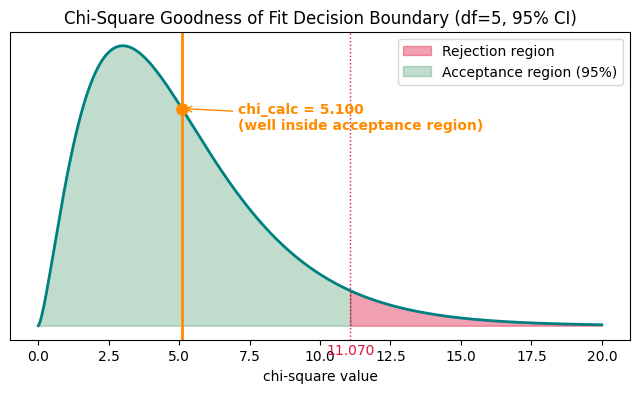

In [9]:
import matplotlib.pyplot as plt

x = np.linspace(0, 20, 500)
y = st.chi2.pdf(x, df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, color="teal", linewidth=2)

# rejection region - right tail only
x_reject = np.linspace(chi_critical, 20, 100)
ax.fill_between(x_reject, st.chi2.pdf(x_reject, df), color="crimson", alpha=0.4, label="Rejection region")

# acceptance region
x_accept = np.linspace(0, chi_critical, 200)
ax.fill_between(x_accept, st.chi2.pdf(x_accept, df), color="seagreen", alpha=0.3, label="Acceptance region (95%)")

ax.axvline(chi_critical, color="crimson", linestyle=":", linewidth=1)
ax.text(chi_critical, -0.01, f"{chi_critical:.3f}", ha="center", va="top", color="crimson")

ax.axvline(chi_calc, color="darkorange", linewidth=2)
ax.plot(chi_calc, st.chi2.pdf(chi_calc, df), "o", color="darkorange", markersize=8, zorder=5)
ax.annotate(f"chi_calc = {chi_calc:.3f}\n(well inside acceptance region)",
            xy=(chi_calc, st.chi2.pdf(chi_calc, df)),
            xytext=(chi_calc + 2, max(y) * 0.7),
            arrowprops=dict(arrowstyle="->", color="darkorange"),
            color="darkorange", fontweight="bold")

ax.legend()
ax.set_yticks([])
ax.set_xlabel("chi-square value")
ax.set_title(f"Chi-Square Goodness of Fit Decision Boundary (df={df}, 95% CI)")
plt.show()

### Cross-Check with `scipy.stats`

`scipy.stats.chisquare` computes the same statistic directly from the observed/expected arrays, and also returns the **p-value** — the probability of seeing a deviation this large (or larger) purely by chance if the die really is fair. A large p-value ($> \alpha$) agrees with "fail to reject $H_0$".

In [10]:
scipy_result = st.chisquare(f_obs=ob, f_exp=ex)
print("scipy chi-square statistic:", scipy_result.statistic)
print("scipy p-value:", scipy_result.pvalue)
print("p-value > alpha (0.05)?", scipy_result.pvalue > alpha, "-> fail to reject H0" if scipy_result.pvalue > alpha else "-> reject H0")

scipy chi-square statistic: 5.1000000000000005
scipy p-value: 0.40379845710420864
p-value > alpha (0.05)? True -> fail to reject H0


---

## FAQ

**1. What's the difference between the "Goodness of Fit" and "Independence" situations mentioned at the top?**

| | Goodness of Fit (this notebook) | Independence |
|---|---|---|
| Number of categorical variables | 1 (the die's face) | 2 (e.g. gender × smoking status) |
| Question asked | Does *this one* variable's distribution match an expected/theoretical distribution? | Are *these two* variables associated, or independent of each other? |
| Data layout | A single list of category counts | A **contingency table** (rows × columns of counts) |
| $E_i$ formula | $E_i = \dfrac{\text{total}}{\text{number of categories}}$ (or any theoretical proportion) | $E_{row,col} = \dfrac{(\text{row total}) \times (\text{column total})}{\text{grand total}}$ |
| Degrees of freedom | $df = k - 1$ ($k$ = number of categories) | $df = (r-1)(c-1)$ ($r$ = rows, $c$ = columns) |
| Example | "Is this die fair?" (this notebook) | "Is smoking status independent of gender?" |

Both situations reuse the **exact same** $\chi^2 = \sum \frac{(O-E)^2}{E}$ formula and the same right-tailed decision rule — only *how $E$ is computed* and *how $df$ is computed* differ, because Independence has two dimensions of categories to account for instead of one.

**2. Why is $df = n-1$ here specifically, and not something else?**

With 6 observed counts that must sum to a fixed total (120 rolls), only 5 of them are free to vary — the 6th is always determined by the other 5 (`120 - sum of the other 5`). That "one less than the number of independent pieces of information" logic is the same reasoning behind $df=n-1$ in the [Paired T-Test notebook](14_Hypothesis_Testing_T-Test_Paired.ipynb), just applied to category counts instead of paired differences.

**3. Why does the Chi-Square test use only the right tail, unlike the two-tailed t-tests in earlier notebooks?**

$\chi^2$ is a **sum of squared** terms, so it can never be negative — a $\chi^2$ near 0 always means "observed matches expected very closely," which is evidence *for* $H_0$, not against it. There is no symmetric "too small" rejection region the way there is for a t-test, so all of $\alpha$ is placed in the right tail where large, real deviations show up.

**4. When would this test conclude the die is biased?**

If any face came up dramatically more or less than ~20 times — e.g. face 6 showing up only 2 times instead of 13 — $\chi^2_{calc}$ would climb past 11.07 and $H_0$ would be rejected. Try changing the `ob` array above (e.g. `[10, 10, 10, 10, 10, 70]`) and re-running the cells to see the statistic cross into the rejection region.